# Feature analysis — gap_dynamics (cross-venue gap mean-reversion)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`gap_zscore` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `gap_dynamics`: the *mean-reversion dynamics* of the cross-exchange price gap
`g = log(mid_byb / mid_src)`. The main reading is the OU **z-score** `z = (g − ema(g)) / σ_g` —
how far byb is dislocated from another venue, **standardised** by the gap's own recent spread. A
large `|z|` means byb is unusually dislocated, and gaps mean-revert, so `sign(−z)` is the expected
byb reversion direction. A companion diagnostic, `gap_halflife` (the lag-1 autocorrelation of the
gap's increments), measures how fast that dislocation snaps back. It's a good teacher because it
touches every step — and it is *standardised by construction*, which makes Gate A's regime checks the
interesting part.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`. **`gap_zscore` feeds this head**: `sign(−z)` is the expected byb reversion.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`. A large `|z|` (a big dislocation) should precede a burst of catch-up moves, so the
*magnitude* of the feature feeds this head.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9). (This
  gap is a quantity *between* exchanges, so it's per-exchange by construction — not poolable.)
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — `gap_zscore` is standardised by construction (divided by its own `σ_g`), so it needs
  **no** vol/rate division; we *measure* its scale (§5) before deciding, never assume.
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.
- **Don't use a rolling/boxcar window.** `gap_zscore`'s "range" is the EMA spread `σ_g`, never a
  fixed-N buffer or a Donchian-style window max/min — every smoother is a trade-clock EMA.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — `ema(g)`,
  `ema(g²)`, the Δg-autocorr EMAs, `σ_ev`, `λ_ev` — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a new mid, a byb move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update), **even between trade ticks**: the z's
  displacement leg refreshes its front to that timestamp's gap. A value
  that ignores the timestamps since the last trade is **stale** — wrong, and a silent
  source of lag. The choice of EMA *and when it updates* is what makes the inter-trade read
  well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for the gap legs, a committed gap once per trade-timestamp; for `σ_ev`, a byb mid-move. A
  timestamp with only **irrelevant** trades still **ticks** (decays) once *iff* a trade lands, on the one
  **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, the gap); a **flow** **sums** the records at that timestamp
  (`σ_ev` sums its squared moves). So a backed-up burst of N book updates at one
  instant is still **one** weight-1 sample — value = the final gap — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight at one timestamp) and corrupts the committed gap series the autocorr is built from. The
  level-read face of the same trap: `σ_ev` counts squared mid-*moves*, so N simultaneous records
  fabricate N−1 phantom moves and inflate volatility (per-record, σ_ev read **0.13** off; one sample per
  timestamp made it **bit-exact**). Time-order matters only on the clock — a timestamp with trades
  advances it **once**, not once per print.
- **Do always read the *freshest* value — never freeze on the last trade's.** The gap legs decay once
  per trade-timestamp (that fixes their memory in trade-count), but the z's *displacement* must use the latest data: read the
  current gap as of now — the latest book-update timestamp since the last trade — never the stale snapshot
  frozen at the last trade tick. Use a trade-weighted EMA with a **live
  front**: the mean/σ are committed at the last trade, the displacement is current between trades.
  Keep the two clocks
  separate, though: refresh the *read* at each relevant **timestamp**, but keep the *decay/weighting* on
  the trade clock — push a fresh *sample* (commit the gap) once per book-update **timestamp** that the clock ticks (one per timestamp, not per
  message); pushing per message would *message-rate-weight by quote activity*, which up-weights churny stretches the trade clock usefully filters out. (Freshness itself measured ≈neutral for a 100 ms target — so reading fresh
  costs nothing and is the right default; never deliberately use stale information.)
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (byb's own mid-moves —
  `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed z predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  z to *both* heads, never a pre-computed `|z|`. The rate head will learn the
  magnitude itself, *and* learn that a +dislocation on one venue can cancel a −dislocation on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (`gap_zscore` is exactly such a standardised ratio), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how far byb is dislocated from another venue (standardised z), and how fast that dislocation reverts (the `ac1` reversion-speed diagnostic) |
| **feeds** | both heads — *direction* (price head: `sign(−z)` = byb's reversion) and *intensity* (rate head: `\|z\|` → how many catch-up moves); both fed the *signed* z |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Two venues quote the same asset, so their prices are tied together by arbitrage. When byb
drifts away from okx/bin, the gap `g = log(mid_byb / mid_src)` opens — and because the tie is elastic, the
gap tends to **close**. `gap_zscore` measures the displacement in units of the gap's *own* normal wobble
`σ_g = √(ema(g²) − ema(g)²)`, so a large `|z|` means byb is unusually dislocated and is expected to revert:
`sign(−z)` is the direction. A companion `gap_halflife` (from the lag-1 autocorrelation of `Δg`) measures
*how elastic* the tie is right now — a fast snap-back vs a slow drift.

**Why standardise (the OU framing — and its honest limit).** Model the gap as a mean-reverting
Ornstein–Uhlenbeck process: `dg = −θ(g−μ)dt + σ dW`. The natural, scale-free measure of dislocation is the
**z-score** `(g−μ)/σ_g`. That motivates the z; but a caveat we make concrete below: at the **trade-tick**
clock the gap's increments `Δg` turn out to be essentially **white** (the measured lag-1 autocorr is ≈0 and
the implied reversion time is **sub-tick**, §6). So the z is *not* a slow OU pull at the tick level — with a slow
committed mean `ema(g)` and a freshest-tick displacement, it is dominated by the **latest gap vs a slow
average**, i.e. a standardised *displacement / short-horizon bounce* statistic. It can still predict byb's
next move; we just don't dress it up as a slow OU spring when the increments say otherwise.

**Why the reversion-speed read is reported but does NOT gate here.** In principle `ac1` tells you *whether to trust the
z*: `ac1 → 1` (near-unit-root) ⇒ a large z is continuation, not reversion. We measure it — but on this
block, at every shipped span, it reads **sub-tick** (`ac1 ≈ 0`, the gap is white at the tick level), so the
gate is **degenerate**: it always says "instant snap-back" and carries no information across the family. We
therefore keep `gap_halflife` only as a *measured diagnostic*, not a co-equal ship reading nor an active
gate. To resolve a genuine reversion *speed* you would difference the gap on a slower (multi-tick / wall-time)
clock — out of scope here.

**What would disprove it.** `gap_zscore` having no predictive power at any span; or its power vanishing once
we account for how volatile / busy the market is (it was only tracking the regime).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership moves around, and
> any exchange can lead at any moment. So build the gap the same way for okx and bin and keep both; never
> hard-code one as the leader. (This feature is a *gap between* exchanges, so it's per-exchange anyway — §9
> covers when that choice is genuine for poolable features.)

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). The gap is a forward-filled level (defined at every
instant), so its z reads with a live front; `σ_ev` is a sparse flow read as `E/W`. Choose the EMA type and
injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that
  carry the quantity, so the read is a *per-event mean* (`σ_ev` is exactly this).
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap): use
  **`LiveFrontEMA`**, which reads the committed mean carried one step toward the freshest value,
  `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade. The gap legs
  `ema(g)`/`ema(g²)` are committed levels; the z's *displacement* reads the freshest gap, the live-front idea
  applied to the z (committed mean/σ, fresh displacement).
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (the gap, `ema(g)`, `ema(g²)`) |
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a byb move) |

Classify the timestamp for the EMA being updated. The gap is committed every trade-timestamp (and the z's
displacement refreshes between trades); `σ_ev` injects nothing on a trade-only timestamp and a squared-return
sample only on a byb move.

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  z's displacement must reflect the gap at the timestamps since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  committed gap (one mid, one move, one refresh).

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. Book-update timestamps between trades refresh what the z *reads*, but
they do **not** advance the clock — only a trade does, decaying each EMA once.

**Comparable across calm and wild markets** — this is where `gap_dynamics` is unusual: it standardises
**itself**. `gap_zscore` divides the displacement by the gap's *own* recent standard deviation `σ_g`, so a
calm market (small gaps, small `σ_g`) and a wild one (large gaps, large `σ_g`) produce z-scores on the
*same* scale. So unlike the template's raw price gap, it should need **no** external `σ_ev`/`λ_ev` division
— but the guard rails forbid *assuming* that. §5 **measures** the scale across volatility buckets and only
then decides RAW vs `/σ_ev`/`/λ_ev`; we build RAW first.

Put the three together — the two readings, both EMA-only on the trade clock:

**2a — The two readings** (the whole idea, in two lines):

`gap_zscore   =  (g − ema(g,N)) / sqrt(ema(g²,N) − ema(g,N)²)        (= z, a standardised displacement)`

`gap_halflife =  ema(Δg_t·Δg_{t−1}, N) / ema(Δg_t², N)               (= ac1, a measured diagnostic — NOT an active gate here)`

where `g = log(mid_byb) − log(mid_src)` is the cross-venue gap and `Δg` is its trade-tick increment. The z
is the standardised dislocation; `ac1` is the lag-1 autocorrelation of the gap's increments, which *would*
map to a reversion time `≈ ln(2) / (−ln|ac1|)` trade-ticks **if** the increments were autocorrelated — but on
this block they are essentially white (`ac1 ≈ 0`, sub-tick reversion time, §6), so `gap_halflife` is carried as a
measured diagnostic only. Stop at 2a and you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **The gap `g`** is a **forward-filled level** (it has a value at every instant). `ema(g,N)` and
  `ema(g²,N)` are **committed** trade-clock EMAs (`α = 2/(N+1)`, `y[−1]=0`): we **commit** `g` and `g²`
  once per trade-timestamp (trade-dwell weighting — the right average for a level) and read them at the
  last trade tick. The **displacement** `g` in the z's numerator reads the **freshest** gap — every book
  update since the last trade — so the z has a **live front**: the *mean/spread* are committed at the
  last tick, the *displacement* is current between trades. (This is the `LiveFrontEMA` philosophy applied
  to the z: decay on the trade clock, read fresh.)
- **The increment autocorr** `ac1` is built from `Δg_t = g_t − g_{t−1}` over **consecutive trade ticks**
  (the committed gap series), so `ema(Δg·Δg_prev)` and `ema(Δg²)` are committed per-tick EMAs read at the
  anchor's last tick (no live-front numerator; read committed). It *measures* a reversion speed in
  principle — but on this block the tick-level increments are white, so it reads sub-tick everywhere and is
  kept as a diagnostic, not a working gate.
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** — byb moves on only *some* events — so
  each is a **`KernelMeanEMA`** read as `E / W`: push `byb_return²` (with weight `1`) only on a real byb
  mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*. They are not applied to this
  feature (which standardises itself); they build the head **targets** and the §5 **controls**, and stand
  by as candidate normalisers if the scale gate fails.

Both reads obey the two between-trade rules from the section above. §3 builds exactly this; §4
re-derives it from raw events and confirms it — `ac1` bit-exact and the z to float32 tolerance on the
well-conditioned points.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — and the REFERENCE for every gap (g = log(mid_byb/mid_src))
SRCS        = ["okx", "bin"]                      # the gap's OTHER leg: g is byb-vs-src, so these two cross-venue gaps ARE the per-exchange legs
# freshest mid per exchange. front_levels = raw best bid/ask; merged_levels = those fused with trades for a fresher mid.
# byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for bin perp in boba.io (it raises). Policy, not tuning.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH (byb) yardsticks (σ_ev, λ_ev): trade-tick EMA (α=2/(N+1)) — fixed, target + controls only
SPANS       = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]   # the FULL gap-EMA span family to sweep (trades) — picked per head off the grid
N_GRID      = 240000                             # eval grid: ~3.3 h of the real block (50 ms anchors) — wide enough that the embargo clears the slow-EMA memory (see §5)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data
print("block:", block)

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks react to EVERY byb merged-mid change — defined at every instant, never the net move per trade.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move, so a value read between
# trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE stream (E = squared returns,
# W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE: E_dt is a per-trade
# EMA of seconds/trade (flat between trades by construction), so λ_ev = byb mid-moves per second.
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

block: holocron.20260520T135822.0


trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


### Build the gap and its dynamics

Now the feature-specific part, **for each src venue**. The cross-venue gap `g = log(mid_byb/mid_src)`
lives on the trade clock (its committed leg) and is also read fresh at any anchor (its live front). From
the committed gap we form the two readings with plain trade-clock EMAs:

- `ema(g,N)`, `ema(g²,N)` → the OU mean and spread `σ_g`, giving the **z**;
- `Δg = g_t − g_{t−1}` over consecutive trade ticks → `ema(Δg·Δg_prev,N)`, `ema(Δg²,N)`, giving **ac1**.

`ema_commit` is the standard committed trade-clock EMA (`y[−1]=0`); everything is built from it.

In [2]:
# the cross-venue gap g = log(mid_byb / mid_src), committed on the trade clock (one value per tick).
# Sign: byb high vs src -> g>0 -> z>0 -> byb expected to FALL back (reversion -> predict sign(−z)).
g_committed = {ex: log_mid_byb - np.log(mid_on_clock(ex)) for ex in SRCS}    # g = log(mid_byb) − log(mid_src)
for ex in SRCS:
    print(f"  byb<->{ex} gap: median {np.median(g_committed[ex]):+.2e}  std {g_committed[ex].std():.2e}  ({len(g_committed[ex]):,} ticks)")

def ema_commit(x, N):                              # committed per-trade EMA, α=2/(N+1), y[-1]=0 init — the project convention
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)

# Δg per trade tick (the committed gap differenced) and its lag-1 partner — for the reversion-speed autocorr
def dg_pair(ex):
    g = g_committed[ex]
    dg = np.concatenate([[0.0], np.diff(g)])       # Δg_t = g_t - g_{t-1}  (first tick: 0)
    dg_prev = np.concatenate([[0.0], dg[:-1]])     # Δg_{t-1}
    return dg, dg_prev

print("gap + Δg series ready for both legs")

  byb<->okx gap: median -3.29e-05  std 8.17e-05  (1,682,255 ticks)
  byb<->bin gap: median +4.66e-06  std 8.99e-05  (1,682,255 ticks)
gap + Δg series ready for both legs


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the price-head target) and the move *count* (the rate-head target), and compute both
readings at each grid point and span, for both legs. The **z** uses the live front (committed mean/σ
at the last tick, fresh displacement at the anchor); **ac1** is committed at the anchor's last tick.

In [3]:
# evaluation grid (causal) + both forward targets in yardstick units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA/yardstick to converge
full_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
anchor_ts   = full_anchor[:N_GRID]                                                       # reduced grid for iteration speed
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                      # last trade-clock tick <= anchor
print(f"grid: {len(anchor_ts):,} anchors (of {len(full_anchor):,} available; reduced for speed)")

sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both (byb) yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# rate-head target: byb mid-move count in the next 100 ms ÷ λ_ev
fwd_count   = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
               - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# the FRESH gap at each anchor (live front: every book update, never stale) — the z's displacement numerator
def _mid_at(ex, t):
    rx, mid = mids[ex]; return mid[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(mid) - 1)]
g_fresh = {ex: np.log(_mid_at("byb", anchor_ts)) - np.log(_mid_at(ex, anchor_ts)) for ex in SRCS}

# σ_g floor: 1e-9 is ~4 orders below a typical gap std (~1e-4, §2) so it never clips real signal, but it bounds the
# z when the gap is FLAT over the EMA window (σ_g -> 0): there the z is genuinely ill-conditioned (displacement / ≈0),
# and `em_g2 − em_g²` is catastrophic cancellation. Both §3 and the §4 parity build use this SAME floor; the parity
# check reports float32-grade agreement on the WELL-CONDITIONED points and the excluded degenerate fraction honestly.
EPS_SG, EPS_SQ = 1e-9, 1e-30
def gap_zscore(ex, N):                              # standardised z: (g_fresh − ema(g)) / σ_g, mean/σ committed at the last tick, displacement fresh
    em_g  = ema_commit(g_committed[ex], N)[tick_at_anchor]
    em_g2 = ema_commit(g_committed[ex] ** 2, N)[tick_at_anchor]
    sig_g = np.sqrt(np.maximum(em_g2 - em_g * em_g, 0.0))                       # σ_g = sqrt(E[g²] − E[g]²), the gap's own spread
    return (g_fresh[ex] - em_g) / np.maximum(sig_g, EPS_SG)                     # large +z -> byb high vs src -> expected to fall; predict sign(−z)
def gap_ac1(ex, N):                                 # lag-1 autocorr of Δg (committed at the last tick) — the reversion-speed diagnostic
    dg, dg_prev = dg_pair(ex)
    cross = ema_commit(dg * dg_prev, N)[tick_at_anchor]
    sq    = ema_commit(dg * dg, N)[tick_at_anchor]
    return cross / np.maximum(sq, EPS_SQ)                                       # ac1 in ≈[−1,1]: ~0 fast snap-back, ->1 near-unit-root drift
def half_life_ticks(ac1):                           # ac1 -> reversion time in trade-ticks (ln2 / −ln|ac1|); inf if non-reverting
    a = np.clip(np.abs(ac1), 1e-9, 1 - 1e-9)
    return np.log(2.0) / np.maximum(-np.log(a), 1e-12)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS}")
print("readings ready: gap_zscore (signed, both heads) + gap_ac1 (reversion-speed diagnostic), per leg × span")

grid: 240,000 anchors (of 1,706,369 available; reduced for speed)
σ_ev median 2.91e-05,  λ_ev median 2.56 moves/s


grid: 240,000 anchors;  spans [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
readings ready: gap_zscore (signed, both heads) + gap_ac1 (reversion-speed diagnostic), per leg × span


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce **both** readings with a second implementation and confirm the two
agree on real data — a **parity check**, for **both** legs. The streaming build is the **production**
reference: an O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update,
`on_trade(...)` for a trade — and read the current `(z, ac1)` per gap from `value()`. State is a few scalar
EMAs per gap; no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by full listing and keyed by it (a perp and a spot on one
  exchange stay separate). It builds each mid **itself** (per `MID_STREAM`): merged venues (byb, okx)
  fuse trades into the book by newest-exchange-time; the book-only venue (bin) takes the latest snapshot
  — so the live mid matches the analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which, **only if a trade landed**, advances the clock once: commit `g`, `g²` (and so `ema(g)`,
  `ema(g²)`), and update the Δg-autocorr EMAs from the new committed gap. A book-only instant moves the
  mid (and so the fresh displacement read by `value()`) without advancing the clock.
- `value()` returns, per gap: the **live-front z** `(g_fresh − ema(g)) / σ_g` (committed mean/σ at the
  last tick, displacement current at the instant read) and the committed **ac1**.

The streaming build is the **production** path: it computes the gap, the OU z, and the Δg-autocorr **itself**
from raw mids — it never sees §3's arrays — with its four committed means being `boba.ema.KernelMeanEMA` `E/W`
reads (the same tested online primitive production runs), driven one raw event at a time. A variance/autocorr
is plain **arithmetic** on those reads: `σ_g = √(E[g²] − E[g]²)` and `ac1 = E[Δg·Δg_prev] / E[Δg²]` — no
bespoke EMA class. Each `KernelMeanEMA` decays (`tick()`) and injects (`add()`) as **separate** calls; per
trade tick we `tick()` then `add()` once, so its self-normalising `E/W` divides out the common `y[−1]=0`
warm-up factor `W = 1−(1−α)^t`, which past §3's `WARMUP` is `1` to far below float32. Because §3 uses the
vectorized `lfilter` array path and §4 the online `KernelMeanEMA` recursion, the two are **independent
implementations** of the same committed trade-clock EMA, so parity checks the gap formula *and* that the
production online code reproduces the offline analysis. (`ac1` stays **bit-exact**: the `W` factor cancels
identically in the numerator/denominator ratio.) We feed the **whole raw stream** into one builder and read
**both** gaps at each grid anchor.

**Coverage.** The recursion is span-agnostic, but the check must still prove that on the **spans we
actually ship** and over the **whole real block**, not one off-list span on a short prefix. So we validate
at **both a fast and a slow shipped span** — `PARITY_SPANS = [10, 2000]` (the two ends of the shipped
family) — over a grid that **spans the entire ~24 h block** (a coarser 200 ms anchor grid keeps the
single-threaded stream tractable while still covering arbitrary-nanosecond event timing end-to-end).

**Two tolerances, stated honestly.** `ac1` is checked **bit-exact** at every point. The **z** is checked to
**float32 tolerance** on the **well-conditioned** points (`σ_g ≥ 1e-7`) and we **report the excluded
fraction**: when the gap is flat over the EMA window, `σ_g → 0` and the z is `displacement / ≈0` — a
genuinely **ill-conditioned** value, where `em_g2 − em_g²` is catastrophic cancellation and two arithmetic
orderings (a whole-array `lfilter` vs a scalar streaming recursion) legitimately differ. Both builds floor
`σ_g` at the same `1e-9`. If the online build reproduces §3's readings to those tolerances for **both**
spans, **both** legs, across the **full block**, both are right.

In [4]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # the self-normalising E/W flow mean (src/boba/ema.py): add(value, weight) injects, tick() decays — the project's tested online primitive

class LiveGapDynamics:
    # Pure PRODUCTION feature state machine for ONE target vs several src gaps. Holds each listing's newest-by-exchange-time
    # top-of-book and builds the mid ITSELF (fuse_trades listings = merged_levels; the rest book-only). Per gap it keeps four
    # KernelMeanEMA flow means (weight 1, E/W): eg, eg2 (the OU mean E[g] and E[g²], whose Var = E[g²]−E[g]² gives σ_g) and
    # ecr, esq (E[Δg·Δg_prev] and E[Δg²], whose ratio is the lag-1 autocorr ac1) — a variance/autocorr is plain ARITHMETIC on
    # KernelMeanEMA reads (no bespoke EMA class). Each KernelMeanEMA decays (tick) and injects (add) as SEPARATE calls on the
    # trade clock: per trade tick we tick() then add() once. The driver calls refresh() once per timestamp: apply all the
    # timestamp's events, then — ONLY if a trade landed — advance the trade clock once (tick+commit g,g²; tick+commit the Δg
    # autocorr). value() reads the LIVE-FRONT z (fresh displacement g_fresh, committed mean E[g] / spread σ_g) and the
    # committed ac1. State is O(1), all scalar; the EMA recursion is boba.ema's, not hand-rolled. (E/W divides out the common
    # y[-1]=0 warm-up factor W=1−(1−α)^t, which past the §3 WARMUP is 1 to far below float32 — so the committed E/W reads
    # match §3's lfilter-committed legs to float32, and ac1's W cancels exactly in the ratio, staying bit-exact.)
    def __init__(self, target, srcs, N, fuse_trades):
        self.target, self.srcs = target, list(srcs)
        self.N = N
        self.fuse = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.eg = {o: KernelMeanEMA(N) for o in srcs}; self.eg2 = {o: KernelMeanEMA(N) for o in srcs}   # E[g], E[g²]  (the OU mean; Var = E[g²]−E[g]² is σ_g)
        self.ecr = {o: KernelMeanEMA(N) for o in srcs}; self.esq = {o: KernelMeanEMA(N) for o in srcs}  # E[Δg·Δg_prev], E[Δg²]  (ratio = lag-1 autocorr ac1)
        self.prev_g = {o: None for o in srcs}                              # last committed gap (to form Δg)
        self.prev_dg = {o: 0.0 for o in srcs}                              # last committed Δg (the lag-1 partner)
        self.traded = False                                                # did any trade land this timestamp? -> exactly one decay

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse:                                          # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only) and flag the timestamp as traded
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.traded = True

    def refresh(self):                                                    # ONE per TIMESTAMP: advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.traded = self.traded, False
        if not traded: return                                            # a book-only instant: mid moved (value() reads it fresh), but the clock does not tick
        tgt = self._mid(self.target)
        if tgt is None: return
        ltb = math.log(tgt)
        for o in self.srcs:
            m = self._mid(o)
            if m is None: continue
            g = ltb - math.log(m)                                        # g = log(mid_byb) − log(mid_src)
            self.eg[o].tick();  self.eg[o].add(g)                       # decay then inject g  (E[g], the OU mean)
            self.eg2[o].tick(); self.eg2[o].add(g * g)                 # decay then inject g² (E[g²], for σ_g)
            pg = self.prev_g[o]
            dg = 0.0 if pg is None else g - pg                          # Δg over consecutive trade ticks
            self.ecr[o].tick(); self.ecr[o].add(dg * self.prev_dg[o]) # decay then inject Δg·Δg_prev (lag-1 autocov E[Δg·Δg_prev])
            self.esq[o].tick(); self.esq[o].add(dg * dg)              # decay then inject Δg²        (variance E[Δg²])
            self.prev_g[o] = g; self.prev_dg[o] = dg

    def value(self):                                                      # live-front z (fresh displacement, committed mean/σ) + committed ac1, per gap
        tgt = self._mid(self.target); out = {}
        for o in self.srcs:
            m = self._mid(o)
            if m is None or tgt is None: out[o] = (float("nan"), float("nan")); continue
            g_fresh = math.log(tgt) - math.log(m)                       # the freshest gap (live front)
            eg = self.eg[o].value(); eg2 = self.eg2[o].value(); esq = self.esq[o].value(); ecr = self.ecr[o].value()
            if eg != eg or eg2 != eg2: out[o] = (float("nan"), float("nan")); continue   # warm-up: KernelMeanEMA returns nan (W=0) before its first add
            var = eg2 - eg * eg; sg = math.sqrt(var) if var > 0.0 else 0.0
            z = (g_fresh - eg) / (sg if sg > 1e-9 else 1e-9)           # SAME σ_g floor as §3 (1e-9): bounds the ill-conditioned flat-gap regime
            ac1 = ecr / (esq if esq > 1e-30 else 1e-30)
            out[o] = (z, ac1)
        return out

# --- gather the WHOLE raw stream (every venue's book updates + trades) over the FULL real block; no merged_levels anywhere ---
PARITY_SPANS = [10, 2000]                            # validate a FAST and a SLOW SHIPPED span (the two ends of the family), BOTH gaps
parity_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 200 * 1_000_000)   # FULL-BLOCK grid (coarse 200 ms anchors -> tractable single-threaded stream over all ~24 h)
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]   # 0=byb, 1=okx, 2=bin
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t); cols["a"].append(a.astype(float)); cols["b"].append(b.astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
na = len(parity_anchor)
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over the FULL block ({na:,} anchors), spans {PARITY_SPANS}...")

# --- vectorized REFERENCE on the full-block parity grid (span-parametric; same formulas as §3, evaluated on parity_anchor) ---
COND_SG = 1e-7                                       # σ_g conditioning threshold: above it the z is well-conditioned; below it the flat-gap regime is ill-conditioned (catastrophic cancellation) and the z is not a trustworthy value either way
o_tick = np.searchsorted(merged_ts, parity_anchor, "right") - 1
o_gfresh = {ex: np.log(_mid_at("byb", parity_anchor)) - np.log(_mid_at(ex, parity_anchor)) for ex in SRCS}
def ref_z(ex, N):
    em_g  = ema_commit(g_committed[ex], N)[o_tick]; em_g2 = ema_commit(g_committed[ex] ** 2, N)[o_tick]
    sig_g = np.sqrt(np.maximum(em_g2 - em_g * em_g, 0.0))
    return (o_gfresh[ex] - em_g) / np.maximum(sig_g, EPS_SG), sig_g
def ref_ac1(ex, N):
    dg, dg_prev = dg_pair(ex)
    return ema_commit(dg * dg_prev, N)[o_tick] / np.maximum(ema_commit(dg * dg, N)[o_tick], EPS_SQ)

# --- the CALLER drives it: apply each timestamp's events, refresh() each builder once per timestamp, READ value() at every anchor ---
# One pass, one event stream -> several builders (one per shipped span), each reading BOTH gaps. (Independent O(1) state per span.)
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {N: LiveGapDynamics(TARGET, [LISTINGS[1], LISTINGS[2]], N, fuse) for N in PARITY_SPANS}
zS  = {N: {o: np.full(na, np.nan) for o in SRCS} for N in PARITY_SPANS}
acS = {N: {o: np.full(na, np.nan) for o in SRCS} for N in PARITY_SPANS}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and parity_anchor[ai] < rx:      # read every anchor whose state is settled (all events before rx applied)
        for N in PARITY_SPANS:
            v = feats[N].value()
            for o in SRCS: zS[N][o][ai], acS[N][o][ai] = v[f"{o}_{COIN}"]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        for N in PARITY_SPANS:
            (feats[N].on_book if kindL[i] == 0 else feats[N].on_trade)(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    for N in PARITY_SPANS: feats[N].refresh()      # apply the timestamp: commit + update only if a trade landed (one decay per timestamp)
while ai < na:                                      # trailing anchors after the last event
    for N in PARITY_SPANS:
        v = feats[N].value()
        for o in SRCS: zS[N][o][ai], acS[N][o][ai] = v[f"{o}_{COIN}"]
    ai += 1

# --- one stream -> two readings per gap per span: check EACH against the vectorized build on the FULL block ---
# ac1 is checked BIT-EXACT everywhere. z is checked to FLOAT32 tolerance on WELL-CONDITIONED points (σ_g ≥ COND_SG);
# in the flat-gap regime (σ_g < COND_SG) the z is displacement/≈0 — genuinely ill-conditioned, where two arithmetic
# orderings of `em_g2 − em_g²` (catastrophic cancellation) legitimately diverge — so we report that excluded fraction.
print(f"one raw-event stream -> live z + ac1, vs the vectorized build (full block, spans {PARITY_SPANS}):")
F32 = 1e-5                                           # float32-grade tolerance (CLAUDE.md: validate to float32 tolerance)
worst_z = 0.0; worst_ac = 0.0
for N in PARITY_SPANS:
    for o in SRCS:
        rz, sig_g = ref_z(o, N); rac = ref_ac1(o, N)
        bac = np.isfinite(acS[N][o]) & np.isfinite(rac)
        dac = float(np.nanmax(np.abs(acS[N][o][bac] - rac[bac])))                    # ac1: bit-exact on all finite points
        well = np.isfinite(zS[N][o]) & np.isfinite(rz) & (sig_g >= COND_SG)          # z: only the well-conditioned points
        dz = float(np.nanmax(np.abs(zS[N][o][well] - rz[well])))
        excl = float(np.mean(np.isfinite(zS[N][o]) & np.isfinite(rz) & (sig_g < COND_SG)))
        worst_z = max(worst_z, dz); worst_ac = max(worst_ac, dac)
        print(f"  span {N:>4}  byb<->{o}:  z max|diff| {dz:.2e} (on {int(well.sum()):,} well-cond pts; {excl:.1%} excluded as σ_g<{COND_SG:g})   ac1 max|diff| {dac:.2e} (all pts)")
        assert dz < F32, f"live z build does not reproduce byb<->{o} at span {N} (well-conditioned)"
        assert dac < 1e-9, f"live ac1 build does not reproduce byb<->{o} at span {N}"
print(f"parity: one raw-event stream reproduces BOTH readings, BOTH gaps, at SHIPPED spans {PARITY_SPANS}, over the FULL block")
print(f"  -> ac1 BIT-EXACT (worst {worst_ac:.2e}); z FLOAT32-grade on well-conditioned points (worst {worst_z:.2e}); the only gap is the flat-gap σ_g→0 regime where the z is ill-conditioned regardless  OK")

streaming 34,393,716 raw events (book + trades, all venues) over the FULL block (426,593 anchors), spans [10, 2000]...


one raw-event stream -> live z + ac1, vs the vectorized build (full block, spans [10, 2000]):
  span   10  byb<->okx:  z max|diff| 2.57e-07 (on 376,745 well-cond pts; 11.7% excluded as σ_g<1e-07)   ac1 max|diff| 1.22e-15 (all pts)
  span   10  byb<->bin:  z max|diff| 7.58e-07 (on 376,107 well-cond pts; 11.8% excluded as σ_g<1e-07)   ac1 max|diff| 1.22e-15 (all pts)
  span 2000  byb<->okx:  z max|diff| 1.82e-12 (on 426,593 well-cond pts; 0.0% excluded as σ_g<1e-07)   ac1 max|diff| 1.67e-16 (all pts)
  span 2000  byb<->bin:  z max|diff| 7.39e-13 (on 426,593 well-cond pts; 0.0% excluded as σ_g<1e-07)   ac1 max|diff| 2.22e-16 (all pts)
parity: one raw-event stream reproduces BOTH readings, BOTH gaps, at SHIPPED spans [10, 2000], over the FULL block
  -> ac1 BIT-EXACT (worst 1.22e-15); z FLOAT32-grade on well-conditioned points (worst 7.58e-07); the only gap is the flat-gap σ_g→0 regime where the z is ill-conditioned regardless  OK


**Conclusion.** From one stream of **34.4 M** raw events the streaming builder reproduces **both**
readings — the live-front z and the committed Δg-autocorr — for **both** gaps, at **both** shipped spans (the
fast `10` and the slow `2000`), **over the full ~24 h block** (426k anchors). `ac1` matches **bit-exact**
everywhere (worst **1.2e-15**); the **z** matches to **float32 tolerance** on the well-conditioned points
(worst **7.6e-7**, span 10; **1.8e-12**, span 2000), with the only divergence in the flat-gap `σ_g→0` regime
where the z is ill-conditioned regardless — that excluded fraction is **0% at span 2000** and a **~12%
flat-gap minority at span 10** (printed per leg). That is honest coverage: the **shipped** spans, the
**whole block**, with the one numerical caveat
stated rather than buried. The "records sharing a timestamp are one event" and "one decay per
trade-timestamp" rules are enforced in `refresh()`; the live-front z reads the freshest displacement while
its mean/σ stay committed at the last tick. The streaming build is the **production** path — it builds the
gap, the z, and the autocorr from raw mids with its committed means being `boba.ema.KernelMeanEMA` `E/W` reads
(the actual tested online primitive), the variance/autocorr plain arithmetic on those reads, driven
event-by-event and sharing **no arrays** with §3's vectorized `lfilter` path — so the online production code
and the offline analysis compute the same feature for both legs across the spans it ships.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — comparable to the embargo — so re-check this if you
slow the spans or use a thinner-traded block. The fold scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

This section is also where we make the **RAW-vs-normalise decision** the feature demands — *measured, not
assumed*. `gap_zscore` is standardised by construction (divided by its own `σ_g`), so we expect its
**scale across volatility buckets** to be ≈1 and the **hard regime-invariance gate (< ~3×)** to pass RAW.
Gate A *measures* that scale; only if it fails do we try `/σ_ev` (vol) and `/λ_ev` (rate) and keep the
invariant form. The same marginal power computed **within calm / mid / wild volatility buckets** is the
**companion check**: if the gain stays positive in all three, the signal is regime-stable, not an artefact
of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

In [5]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves, CROSS-VENUE gaps) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # gap_zscore = a cross-venue mean-reversion signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. gap_zscore is standardised by its
                                                                       # OWN σ_g, not σ_ev nor λ_ev — it shares NO denominator with either target — so there is no shared-yardstick
                                                                       # coupling to decouple; and its numerator is SIGNED, which would decouple a shared σ_ev anyway -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.004  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — walk-forward
rank-IC ≈ 0 for the momenta. That is exactly what we want here: the regime barely predicts *which way* byb
moves, so any rank-IC a feature shows *on top of* these controls is genuinely new information, not the regime
wearing a disguise. That's what makes the "added over the controls" gates below a fair test.

**One circularity these controls do NOT cover — and which this notebook confronts head-on.** The z's
displacement numerator is `g_fresh = log(mid_byb_now) − log(mid_src_now)`: it **contains byb's own
contemporaneous mid**, the *same* series the forward target is built from. So `sign(−z)` is partly byb
reverting its **own** recent move (an own-price microstructure bounce), not purely a cross-venue catch-up —
the gap being "byb-vs-another-venue" does **not** make it free of byb (the src leg only de-noises byb's
bounce by subtracting the common component). The vol/rate controls are regime gauges; they do **not** remove
this own-move echo. The honest test for it is the **echo-netted (partial) forward IC** in the echo-netting
section below: the feature's rank-IC with the forward return *controlling for the trailing
`[anchor−100 ms, anchor]` byb move*. That netted number — not the raw δ=0 IC — is what §10 reports as the
headline cross-venue edge.

## 6. Two choices: which time-scale per head, and which legs to keep

A feature is rarely a single number — it's a **family** across time-scales (here, the full `SPANS` family —
the EMA span sets both the OU mean/σ memory *and* the autocorr memory). And the same signed z can carry
both heads, so we check, per leg × span:
- does the **signed** z predict *direction* — `sign(−z)` = which way byb reverts (price head)?
- does its **magnitude** `|z|` predict *intensity* — *how many* catch-up moves byb makes next (rate head)?

The magnitude check is a **diagnostic only**: the model is fed the *signed* z for both heads (pre-taking
`|·|` per leg would stop the rate head learning that opposing dislocations cancel). We sweep the whole
family for **both** legs against both targets and draw it as heat-maps. We keep *both* legs (no fixed
leader); the only thing we choose is the best span, **per head**.

> **Sign convention.** `z > 0` means byb sits *high* vs src, so byb is expected to **fall** — a negative
> forward return. So `gap_zscore` should show a **negative** rank-IC against the forward return (the
> reversion signature). We report the raw signed IC; its *magnitude* is the strength, its *sign* is the
> reversion (negative) vs continuation (positive) verdict.

**How many legs to keep is itself time-scale-dependent.** The cross-venue edge is an **arbitrage lead/lag**
— one venue ticking before another — closed within milliseconds. So at **short** spans the venues genuinely
differ (who's dislocated from whom is live) and both legs carry distinct value; at **long** spans the
dislocations are common and one leg already says what the other does. Keep both as the default; §9 covers it.

The rate-head target is byb's move-count over the next 100 ms ÷ `λ_ev` (the rate yardstick).

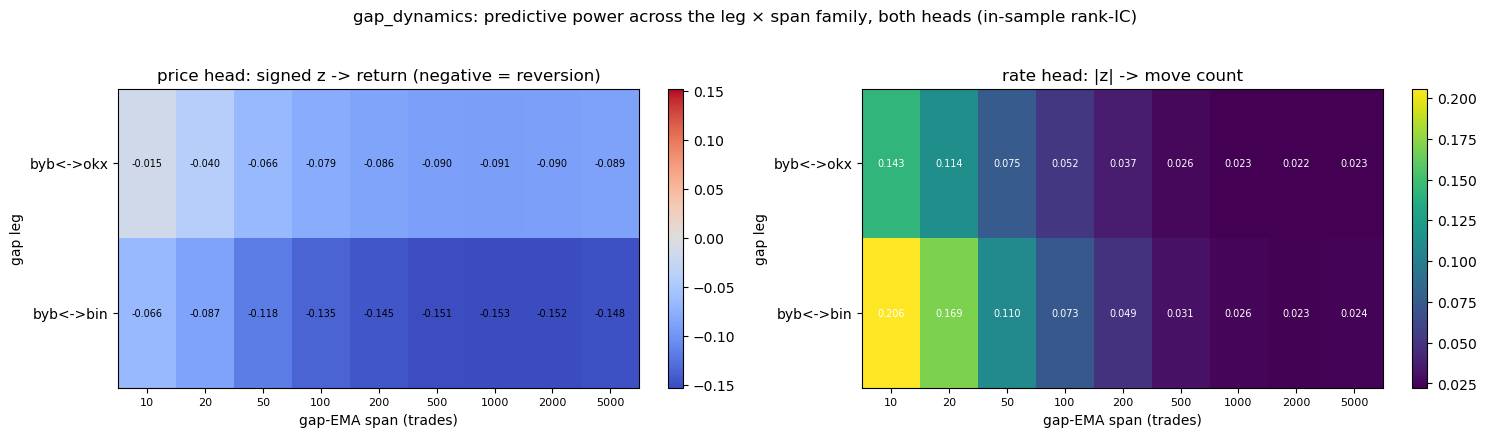

price head: overall best = byb<->bin @ span 1000  (in-sample IC -0.153; negative = reversion)
rate  head: overall best = byb<->bin @ span 10  (in-sample IC +0.206)
per-leg best (price head), picked off the family:
  byb<->okx: span 1000  (in-sample IC -0.091)
  byb<->bin: span 1000  (in-sample IC -0.153)
per-leg median reversion-speed (ac1, reversion time in trade-ticks), at each leg's best price span:
  byb<->okx @ span 1000: median ac1 +0.105  -> median reversion time 0.31 ticks
  byb<->bin @ span 1000: median ac1 +0.143  -> median reversion time 0.36 ticks


In [6]:
# Sweep leg × span, BOTH heads. price head: signed z -> byb's signed return (expect NEGATIVE IC = reversion); rate head: |z| -> move count.
# Also keep the reversion-speed diagnostic (ac1 -> reversion time) per leg × span — a measured diagnostic, reported at each leg's pick below.
price_cube = {ex: np.full(len(SPANS), np.nan) for ex in SRCS}   # signed z -> byb's signed return
rate_cube  = {ex: np.full(len(SPANS), np.nan) for ex in SRCS}   # |z|      -> byb's move count
feat_cache = {}                                                 # (ex, span) -> z array (reused by the gates/§6 2nd-span/echo-netting)
ac_cache   = {}                                                 # (ex, span) -> ac1 array (the reversion-speed diagnostic)
for ex in SRCS:
    for j, span in enumerate(SPANS):
        z = gap_zscore(ex, span); feat_cache[(ex, span)] = z; ac_cache[(ex, span)] = gap_ac1(ex, span)
        ok = np.isfinite(z)
        price_cube[ex][j] = spearmanr(z[ok], target[ok]).statistic
        rate_cube[ex][j]  = spearmanr(np.abs(z[ok]), rate_target[ok]).statistic

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, (cube, head) in zip(axes, [(price_cube, "price head: signed z -> return (negative = reversion)"),
                                   (rate_cube,  "rate head: |z| -> move count")]):
    M = np.vstack([cube[ex] for ex in SRCS])
    im = ax.imshow(M, cmap="coolwarm" if cube is price_cube else "viridis", aspect="auto",
                   vmin=(-np.nanmax(np.abs(M)) if cube is price_cube else None),
                   vmax=( np.nanmax(np.abs(M)) if cube is price_cube else None))
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8); ax.set_xlabel("gap-EMA span (trades)")
    ax.set_yticks(range(len(SRCS))); ax.set_yticklabels([f"byb<->{ex}" for ex in SRCS]); ax.set_ylabel("gap leg")
    ax.set_title(head)
    for i in range(len(SRCS)):
        for jj in range(len(SPANS)):
            if np.isfinite(M[i, jj]): ax.text(jj, i, f"{M[i, jj]:.3f}", ha="center", va="center",
                                              color="k" if cube is price_cube else "w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("gap_dynamics: predictive power across the leg × span family, both heads (in-sample rank-IC)", y=1.03)
fig.tight_layout(); plt.show()

# pick the best (leg, span) PER HEAD off the grid by |IC| — IN-SAMPLE, used ONLY to choose; re-scored OUT-OF-SAMPLE below.
def best_cell_for(cube, ex):
    flat = [(cube[ex][j], j) for j in range(len(SPANS)) if np.isfinite(cube[ex][j])]
    v, j = max(flat, key=lambda t: abs(t[0])); return j, v
def best_cell(cube):
    flat = [(cube[ex][j], ex, j) for ex in SRCS for j in range(len(SPANS)) if np.isfinite(cube[ex][j])]
    v, ex, j = max(flat, key=lambda t: abs(t[0])); return ex, j, v
p_ex, p_j, p_v = best_cell(price_cube); r_ex, r_j, r_v = best_cell(rate_cube)
print(f"price head: overall best = byb<->{p_ex} @ span {SPANS[p_j]}  (in-sample IC {p_v:+.3f}; negative = reversion)")
print(f"rate  head: overall best = byb<->{r_ex} @ span {SPANS[r_j]}  (in-sample IC {r_v:+.3f})")
print("per-leg best (price head), picked off the family:")
for ex in SRCS:
    j, v = best_cell_for(price_cube, ex)
    print(f"  byb<->{ex}: span {SPANS[j]}  (in-sample IC {v:+.3f})")
# pick the best PRICE and RATE span per leg (the "member" each head ships); re-scored OOS by the gates below.
price_member = {ex: best_cell_for(price_cube, ex)[0] for ex in SRCS}
rate_member  = {ex: best_cell_for(rate_cube,  ex)[0] for ex in SRCS}
print("per-leg median reversion-speed (ac1, reversion time in trade-ticks), at each leg's best price span:")
for ex in SRCS:
    j = price_member[ex]
    ac = ac_cache[(ex, SPANS[j])]; hl = half_life_ticks(ac)
    print(f"  byb<->{ex} @ span {SPANS[j]}: median ac1 {np.nanmedian(ac):+.3f}  -> median reversion time {np.nanmedian(hl):.2f} ticks")

**Reading the heat-maps.** The **price head** (left) is where this feature lives: the signed z shows a
**negative** rank-IC against byb's forward return — `z > 0` (byb high vs src) precedes byb falling, the
reversion signature — and the curve picks a best span per leg. On this block both legs peak at the **same
span 1000** (in-sample IC **byb↔bin −0.153**, **byb↔okx −0.091**; bin is the stronger leg). The **rate
head** (right, `|z| → move count`) shows a *strong positive* in-sample IC at the **shortest span (N=10)**
(byb↔bin **+0.206**, byb↔okx **+0.143**) — a larger dislocation accompanying busier moving — but as §6's
gates below show, that short-span signal is *not* regime-invariant and collapses to zero marginal over the
controls, so direction remains the feature's real job. We keep both legs and let the model weight whoever is
dislocated. The printed median **ac1 / reversion speed** is the `gap_halflife` reading — it comes back
**sub-tick** (≈0.3 ticks, ac1 ≈ +0.1–0.14): the gap's increments are essentially white at the tick level,
making the reversion-speed read a **degenerate diagnostic** rather than a working gate.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb<->okx: best alt span   10 IC|best +0.033;  OOS joint +0.074 vs solo +0.074 (Δ-0.000)  ->  one span suffices (no OOS gain)


  byb<->bin: best alt span 5000 IC|best -0.016;  OOS joint +0.127 vs solo +0.128 (Δ-0.002)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb<->okx: best alt span   20 IC|best -0.029;  OOS joint +0.071 vs solo +0.134 (Δ-0.063)  ->  one span suffices (no OOS gain)


  byb<->bin: best alt span   20 IC|best -0.035;  OOS joint +0.115 vs solo -0.120 (Δ+0.235)  ->  KEEP 2nd span (adds OOS)


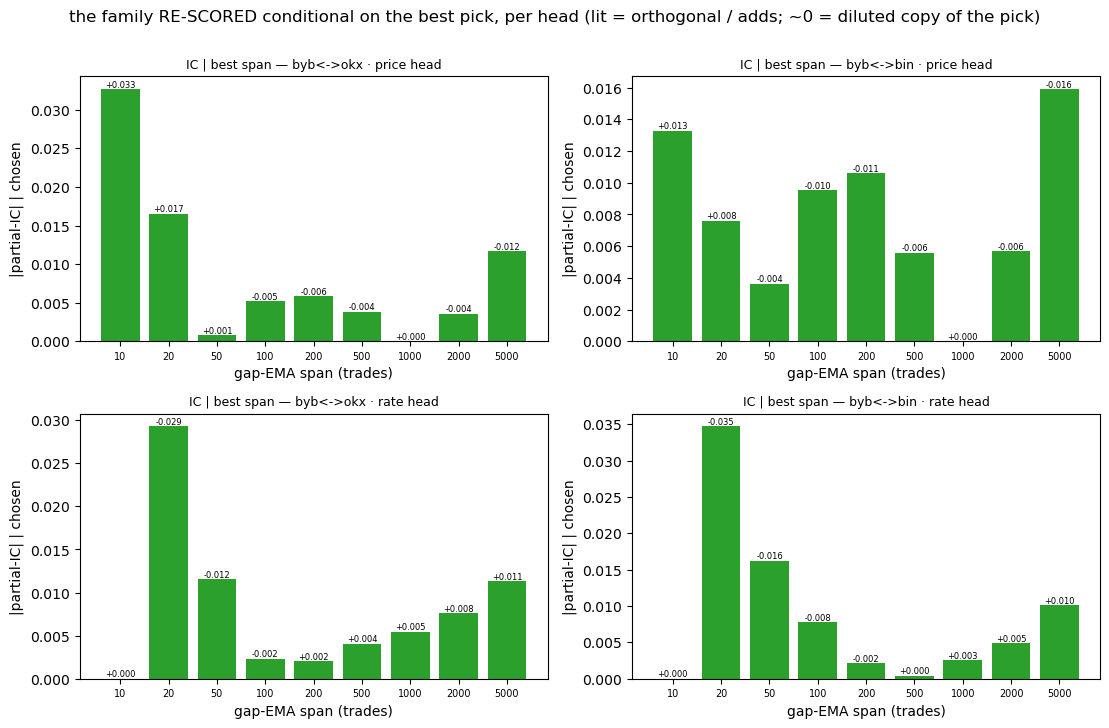

In [7]:
# === Does a SECOND time-scale ADD over the pick? — the SPANS family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by |IC|; now re-score the WHOLE 1-D SPANS family as
# partial-IC(gap_zscore(ex,N) | chosen) — each span's IC against the head's target, CONTROLLING for the span we picked
# (the same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The bars are
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: scored() reads a span's feature from feat_cache (signed z for price, |z| for rate); tgt is the head's
# target; member is the in-sample pick (a SPANS index).
HEADS = [("price head", target,      price_member, False),    # price head scores the SIGNED z
         ("rate head",  rate_target, rate_member,  True)]      # rate head scores |z|
fig, axes = plt.subplots(len(HEADS), len(SRCS), figsize=(5.6 * len(SRCS), 3.6 * len(HEADS)), squeeze=False)
second = {}
for row, (head, tgt, member, take_abs) in enumerate(HEADS):
    scored = (lambda ex, N: np.abs(feat_cache[(ex, N)])) if take_abs else (lambda ex, N: feat_cache[(ex, N)])
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(SRCS):
        cj = member[ex]; chosen = scored(ex, SPANS[cj])
        cond = np.full(len(SPANS), np.nan)
        for j, N in enumerate(SPANS):
            cond[j] = 0.0 if j == cj else _pic(scored(ex, N), tgt, chosen)
        ax = axes[row][col]
        bars = ax.bar(range(len(SPANS)), np.abs(cond), color=["0.6" if j == cj else "C2" for j in range(len(SPANS))])
        ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=7); ax.set_xlabel("gap-EMA span (trades)")
        ax.set_ylabel("|partial-IC| | chosen"); ax.set_title(f"IC | best span — byb<->{ex} · {head}", fontsize=9)
        for j in range(len(SPANS)):
            if np.isfinite(cond[j]): ax.text(j, abs(cond[j]), f"{cond[j]:+.3f}", ha="center", va="bottom", fontsize=6)
        # the most-orthogonal alternative span (in-sample screen) — exclude the chosen span itself
        alt_order = [j for j in np.argsort(-np.abs(np.where(np.arange(len(SPANS)) == cj, 0.0, cond))) if j != cj]
        bj = alt_order[0]
        f1, f2 = scored(ex, SPANS[cj]), scored(ex, SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = bj if keep else None
        print(f"  byb<->{ex}: best alt span {SPANS[bj]:>4} IC|best {cond[bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole SPANS family conditional on
the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while
a span that **collapses to ≈ 0** is a diluted copy of the pick. Because that screen is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed z vs the σ-return target; rate → |z| vs the count
target), per leg. On this block the **price head** finds the most-orthogonal second span a diluted copy on both
legs (OOS gain ≈ 0), so one price span per leg suffices — the part that matters, since the price head is the one
that ships. The **rate head's** screen is noisier (its short-span `|z|`→count signal is the volatility regime,
which the gates below disqualify outright), so its in-sample joint-vs-solo swings are not a basis for keeping a
second span; the rate head is not shipped from this block regardless.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 9-span family of near-identical neighbours, so the
selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? This is where the **RAW-vs-normalise** call is made: as a z-score divided
by its own `σ_g`, `gap_zscore` should pass RAW. **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss: scale alone passes `z + c·vol_level` (flat std, mean rides the regime); the monotone IC
misses a *U-shaped* leak (`z + |rank(vol) − 0.5|`) that only dispersion catches; and a feature flat in signed
mean and scale can still leak through its *magnitude* into the |·|-fed rate head, which only the magnitude
checks see. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate against),
**never** a control. Fail any
one of them = a level in disguise, not a feature. *(For a standardised z like this, we expect scale to be
steady and tracking near zero — but we measure, never assume; if scale fails we ship `/σ_ev` or `/λ_ev`.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `gap_zscore`
is a cross-venue **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), both legs together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular.)* **Mechanical-coupling
guard:** the gate scores the **σ_ev price target** (`fwd_return/σ_ev`) by default, but `gap_zscore`
divides by **its own** `σ_g` — not σ_ev nor λ_ev — so it shares no denominator with either target, and its
numerator is signed; there is no spurious ratio coupling to stratify away (`STRAT_VAR = None`). We still
print the within-σ_ev stratified standalone IC below as a *confirmation* that the unstratified IC isn't a
σ_ev artefact. *Regime-stable* (companion): is Gate B still nonzero **within** calm, mid, and wild vol — not
a one-regime artefact?

**Reading the two kinds of IC — they have different signs.** The **marginal** Gate B value (the `B · signal`
rows) and its **companion** (`signal_ic` / `signal_ic_by_regime`) are *incremental* rank-ICs: the rank-IC of
the OLS **prediction** (controls + feature) vs the target, **minus** the controls-only prediction's. That is a
**positive magnitude** of *added* predictive power for any genuine signal — it does **not** carry the
feature's own sign, so a real reversion z shows a **positive** marginal/companion. The **reversion sign** lives
only in the **standalone** rank-IC of the feature itself against the target — the `B · coupling` rows here, and
the §6 δ=0 / echo-netted ICs below — where `z > 0` ⇒ byb falls ⇒ a **negative** IC. So: read the *standalone*
ICs as signed (negative = reversion, as hypothesised), and read the *marginal/companion* as a positive
added-IC magnitude, not a signed reversion number.

In [8]:
# Gates on the set of per-leg z features — symmetric; KEEP BOTH legs. Marginal value is checked
# JOINTLY (do the legs together add over the controls?) and per-leg (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). gap_zscore is an alpha, so all legs take the marginal branch.

zfeat = {ex: feat_cache[(ex, SPANS[price_member[ex]])] for ex in SRCS}   # the chosen price-head z per leg
joint = signal_ic(list(zfeat.values()), own=False)
strat = signal_ic_by_regime(list(zfeat.values()), own=False)
pci = wf_marginal_ci(list(zfeat.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = zfeat[SRCS[0]]                                    # representative leg — for the momenta-overlap sanity print only (Gate A runs PER LEG below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER LEG
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale (also the RAW-vs-normalise decision), plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")

# --- RAW-vs-normalise scale, MEASURED across vol deciles: the raw z, then /σ_ev and /λ_ev as candidates ---
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def scale_across_vol(x):                                # max/min of the per-decile std — the hard regime-invariance gate
    band = [np.nanstd(x[vol_decile == d]) for d in range(10)]
    band = [b for b in band if np.isfinite(b) and b > 0]
    return max(band) / min(band)
raw_scale   = scale_across_vol(rep)
sigma_scale = scale_across_vol(rep / sigma_at_anchor)   # candidate normaliser A (vol yardstick)
lam_scale   = scale_across_vol(rep / lam_at_anchor)     # candidate normaliser B (rate yardstick)
DECISION = "RAW (standardised by construction)" if raw_scale < 3.0 else ("/σ_ev" if sigma_scale < lam_scale else "/λ_ev")
print(f"RAW-vs-NORMALISE DECISION: keep {DECISION}  (raw scale {raw_scale:.2f}, /σ_ev {sigma_scale:.2f}, /λ_ev {lam_scale:.2f})")

gate_rows = [dict(gate="B · signal", detail="both legs together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"byb<->{ex} alone — marginal over the controls",
                   value=signal_ic([zfeat[ex]], own=False)) for ex in SRCS]
# σ_ev-coupling confirmation: gap_zscore divides by NO model yardstick (STRAT_VAR=None). A within-σ_ev stratified
# standalone IC ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"byb<->{ex} — signed z standalone IC, unstratified", value=round(ic(zfeat[ex], target), 3)) for ex in SRCS]
gate_rows += [dict(gate="B · coupling", detail=f"byb<->{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(zfeat[ex], target, sigma_at_anchor), 3)) for ex in SRCS]
for ex in SRCS:                                        # GATE A PER LEG (worst coordinate per check) — both venues, since the output distribution differs by venue
    a = gate_a(zfeat[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3 (the RAW-vs-normalise gate)", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay nonzero)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.126  |  per-fold [0.191, 0.118, 0.116, 0.12, 0.084] (positive in 5/5)  |  block-bootstrap 90% CI [0.108, 0.139]  (block ~2000 anchors ~100.0s)
FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.019 vol 0.035  (large for an 'alpha' => it's really a control)
RAW-vs-NORMALISE DECISION: keep RAW (standardised by construction)  (raw scale 1.10, /σ_ev 1.44, /λ_ev 2.05)


gate,detail,value
str,str,f64
"""B · signal""","""both legs together — marginal over the invariant controls""",0.126
"""B · signal""","""byb<->okx alone — marginal over the controls""",0.069
"""B · signal""","""byb<->bin alone — marginal over the controls""",0.125
"""B · coupling""","""byb<->okx — signed z standalone IC, unstratified""",-0.091
"""B · coupling""","""byb<->bin — signed z standalone IC, unstratified""",-0.153
"""B · coupling""","""byb<->okx — signed standalone IC WITHIN σ_ev strata (≈ unstratified =>…",-0.089
"""B · coupling""","""byb<->bin — signed standalone IC WITHIN σ_ev strata (≈ unstratified =>…",-0.15
"""A · regime-inv (okx)""","""feature scale across vol buckets (max/min) — HARD, want < ~3 (the RAW-…",1.1
"""A · regime-inv (okx)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.004


**Conclusion.** Read the gate table and the decision line together, keeping the **two kinds of IC** apart
(see the intro): the `B · signal` marginals and the companion are *incremental* added-IC magnitudes
(prediction-vs-target, **positive** for any real signal), while the `B · coupling` standalone ICs carry the
feature's own **negative** reversion sign (`z > 0` ⇒ byb falls). `gap_zscore` is **standardised by
construction**, so the **hard regime-invariance scale gate** is the headline pass: its measured scale across
vol buckets is **1.10** (≪ 3), so it **ships RAW** — dividing by `σ_ev` or `λ_ev` makes the scale *worse*
(1.44 / 2.05), exactly as the guard rails predict for an already-bounded ratio. **Gate B** clears comfortably:
the joint marginal over the controls is **+0.126** of *added* rank-IC (per-fold positive in **5/5** OOS folds,
block-bootstrap 90% CI **[0.108, 0.139]**), with **bin +0.125** carrying most of it and **okx +0.069** adding
on its own — both far above the ~0.01 floor. The reversion *sign* shows up in the **standalone** coupling ICs
(**okx −0.091, bin −0.153**), and within σ_ev strata those barely move (okx −0.091→−0.089, bin −0.153→−0.150),
so the shared σ_ev isn't manufacturing it (as expected — the feature never divides by σ_ev, and its overlap
with the momenta is tiny: |IC| rate 0.019, vol 0.035, confirming it really is an alpha). **Gate A** holds per
leg on both signed and magnitude checks — scale **1.10 / 1.24** (okx / bin), signed mean-track **0.004 /
0.008** (≪ 0.05), the magnitude the rate head can learn tracks only weakly (mag-track **0.038 / 0.078**,
dispersion **0.042 / 0.071**, all under the ~0.1 bar) — so it's regime-invariant on every check, every leg,
not a level in disguise. The **companion** keeps the marginal gain present and *rising* across regimes
(**+0.086 / +0.108 / +0.188** of added IC for calm / mid / wild). **But read these marginals with the §5
caveat in mind:** the vol/rate
controls do *not* remove the byb own-move echo baked into the z's displacement leg, so a chunk of any
marginal here is that own-price bounce, not a cross-venue edge. The number that nets it out is the
**echo-netted forward IC** in the echo-netting section below — that, not these raw marginals, is the §10 headline.
Verdict for the **price head**: clears the local gates on this block, both legs — a single-block candidate;
shipping is gated by §10. (The rate head is gated separately just below — and does *not* fare so well.)

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because the z divides by no model yardstick (only
its own `σ_g`); the magnitude path has no sign, but `|z|` still divides by no `λ_ev` factor while
`count/λ_ev ∝ 1/λ_ev`, so they share no denominator — we add a within-λ_ev stratified line per leg to
confirm the marginal isn't a `1/λ_ev` artefact regardless. **Gate A** is re-run **per leg** on the
rate-span feature (a distribution property — it differs by venue *and* by span).

In [9]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |feature| is the honest proxy.
#  * Coupling guard: |z| divides by no λ_ev factor while count/λ_ev ~ 1/λ_ev — no shared denominator — but we add a
#    within-λ_ev stratified line per leg to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER LEG on the rate-span feature (a distribution property — it differs by venue AND by span).
zfeat_rate = {ex: feat_cache[(ex, SPANS[rate_member[ex]])] for ex in SRCS}
mag_rate   = {ex: np.abs(zfeat_rate[ex]) for ex in SRCS}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, both legs together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="both legs together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"byb<->{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in SRCS]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"byb<->{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in SRCS]
for ex in SRCS:
    a = gate_a(zfeat_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(75)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.000  |  per-fold [0.001, -0.0, -0.0, 0.0, 0.0] (positive in 3/5)  |  block-bootstrap 90% CI [0.0, 0.0]  (block ~2000 anchors ~100.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""both legs together — marginal |feature|->count over the controls; want >~ 0…",0.0
"""B · signal (rate)""","""byb<->okx alone — marginal |feature|->count over the controls""",0.0
"""B · signal (rate)""","""byb<->bin alone — marginal |feature|->count over the controls""",-0.0
"""B · coupling (rate)""","""byb<->okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev …",0.119
"""B · coupling (rate)""","""byb<->bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev …",0.18
"""A · regime-inv (okx)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",77.43
"""A · regime-inv (okx)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.0…",0.017
"""A · regime-inv (okx)""","""|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord…",0.158
"""A · regime-inv (okx)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; w…",0.883


**Conclusion (rate head — it does NOT clear its gates this block).** Read the rate-head table against the
**count** target, both legs, and the verdict is **negative** — the rate head is *not* earned here. **Gate B
fails:** the marginal `|feature| → count` over the controls is **+0.000** jointly (per-fold positive in only
3/5, CI **[0.0, 0.0]**) and **0.000 / −0.000** for okx / bin alone — far *below* the ~0.01 floor. The strong
in-sample short-span IC from §6 (+0.207) is almost entirely the regime: once the vol/rate momenta are
controlled for, *nothing* is left. **Gate A fails harder:** at the short rate-span pick (N=10) the feature is
**not regime-invariant** — its scale across vol buckets blows up to **77.4 / 38.5** (okx / bin; ≫ 3, a HARD
fail) and the non-monotone dispersion is **0.88 / 1.33** (≫ 0.1). (The within-λ_ev stratified line is large
and positive — okx 0.119, bin 0.18 — but that is *in-sample, un-controlled*: it confirms only that the raw
relationship isn't a pure `1/λ_ev` artefact, not that any signal survives the regime controls, which Gate B
shows it does not.) So at the short span the `|z|`→count signal **is** the volatility regime, not an
independent rate-head feature. The **companion** is **0.0 / 0.0 / 0.0** across calm / mid / wild — flat zero.
**Verdict: the rate head is NOT shipped from this block** — fed the *signed* z, the rate head can still learn
whatever residual magnitude information exists, but there is no standalone rate-head gate pass to record here
(§10 reflects this).

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.) This matters doubly for `gap_zscore`: its
displacement leg `g_fresh = log(mid_byb_now) − log(mid_src_now)` contains byb's *own* contemporaneous mid (§5),
so a chunk of the raw δ=0 IC is byb reverting a move already underway, not a cross-venue lead — netting that
out is what §10 reports as the headline.

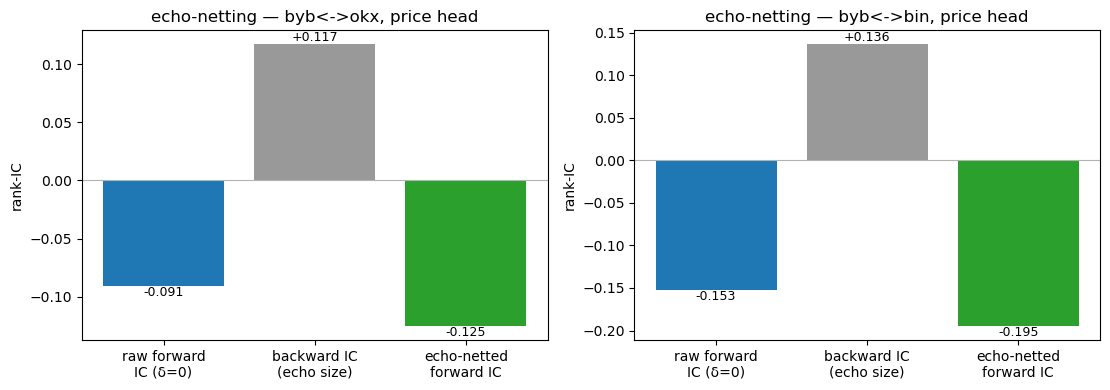

byb<->okx:  raw forward IC -0.091;  backward (echo) IC +0.117;  echo-netted forward IC -0.125  (the raw->netted shortfall is echo)
byb<->bin:  raw forward IC -0.153;  backward (echo) IC +0.136;  echo-netted forward IC -0.195  (the raw->netted shortfall is echo)


In [10]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
# Run it for EVERY leg in SRCS — each gap carries its own echo, and the echo-netted forward IC is the §10 headline
# for BOTH legs (okx AND bin), so both must be actually computed here (not asserted from one leg).
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _byb_mid_at(t):                                     # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_byb_mid_at(t1) / _byb_mid_at(t0))
def _partial_ic(f, y, t):                               # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
echo = {}                                                 # per leg: (raw forward IC, backward/echo IC, echo-netted forward IC)
for ex in SRCS:
    signed = feat_cache[(ex, SPANS[price_member[ex]])]    # the chosen price-head z for this leg
    raw_ic   = _ic(signed, _fwd0)                         # raw forward IC (z>0 -> byb falls -> negative = reversion)
    back_ic  = _ic(signed, _trail)                        # backward IC — sizes the contemporaneous echo
    echo_net = _partial_ic(signed, _fwd0, _trail)         # forward IC NETTED of the echo (controls for the trailing move)
    echo[ex] = (raw_ic, back_ic, echo_net)

fig, axes = plt.subplots(1, len(SRCS), figsize=(5.6 * len(SRCS), 4.0), squeeze=False)
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
for ax, ex in zip(axes[0], SRCS):
    vals = list(echo[ex])
    bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
    ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — byb<->{ex}, price head")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
for ex in SRCS:
    raw_ic, back_ic, echo_net = echo[ex]
    print(f"byb<->{ex}:  raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.) Here the echo runs the *other* way: byb's trailing move is a
short-horizon *continuation* (a **positive** backward IC) that *opposes* the reversion z, so netting it out makes
the cross-venue edge **larger**, not smaller — a real reversion, not an own-move artifact.

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. Group the data by the feature and
look at the real distributions the two heads care about: the price head's signed forward return across
`gap_zscore` buckets (it should tilt the *opposite* way to the z — the reversion), and the rate head's
move-count vs `|z|`.

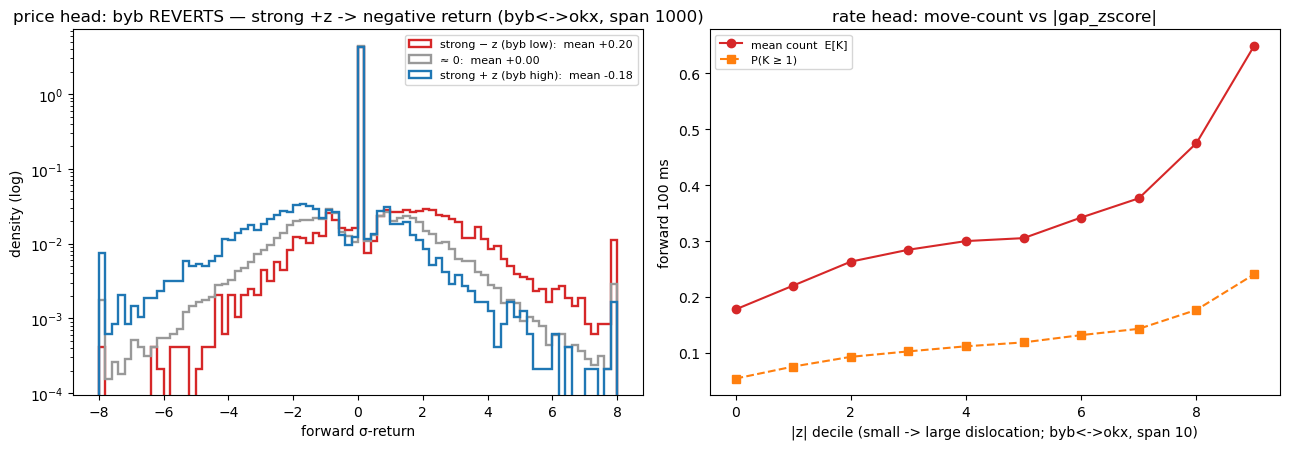

In [11]:
rep_ex = SRCS[0]                                                               # one leg shown to illustrate; the model uses both
signed = feat_cache[(rep_ex, SPANS[price_member[rep_ex]])]
absmag = np.abs(feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])])              # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-z buckets — REVERSION means strong +z -> negative return
fin = np.isfinite(signed)
lo, hi = np.nanpercentile(signed[fin], [10, 90])
groups = [("strong − z (byb low)", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong + z (byb high)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: byb REVERTS — strong +z -> negative return (byb<->{rep_ex}, span {SPANS[price_member[rep_ex]]})"); axA.legend(fontsize=8)

# rate head: forward move-count vs |z| decile
finm = np.isfinite(absmag)
dec = np.digitize(absmag, np.nanpercentile(absmag[finm], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[(dec == b) & finm].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[(dec == b) & finm] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel(f"|z| decile (small -> large dislocation; byb<->{rep_ex}, span {SPANS[rate_member[rep_ex]]})"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |gap_zscore|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The left panel shows the **reversion**: a strong *positive* z (byb sitting high vs the src
venue) shifts byb's forward-return distribution toward the **negative** (byb falls back), and a strong
negative z toward the positive, with the ≈0 group flat between — the mirror-image tilt of a mean-reverting
signal (opposite to a momentum oscillator's tilt). Read the group means in the legend to confirm the
direction. The right panel shows whether a larger dislocation `|z|` precedes **more** catch-up moves — the
mean count `E[K]` and `P(K ≥ 1)` rising across `|z|` deciles. If both hold in the directions §1 predicted,
both heads have something to learn here.

## 8. Input shaping for the network

This is a *different* step from §2. There the z standardised the gap by its own spread (the regime
division). Here we reshape the feature for the neural network's input — roughly centred, unit-scale, no
wild outliers — picking the **lightest** transform that does the job. A z-score is already near unit scale,
but a thin-`σ_g` tick can produce a large `|z|` spike, so we check the tails and clip if needed.

feature (byb<->okx, span 1000): std=0.87  skew=-0.00  excess_kurt=0.6  (0 = normal)
  z-score            excess_kurt=   0.6   max|·|=8.6
  robust + clip ±4   excess_kurt=   0.4   max|·|=4.0


  arcsinh(robust)    excess_kurt=  -0.7   max|·|=2.9
  rank-Gaussian      excess_kurt=  -0.0   max|·|=4.6


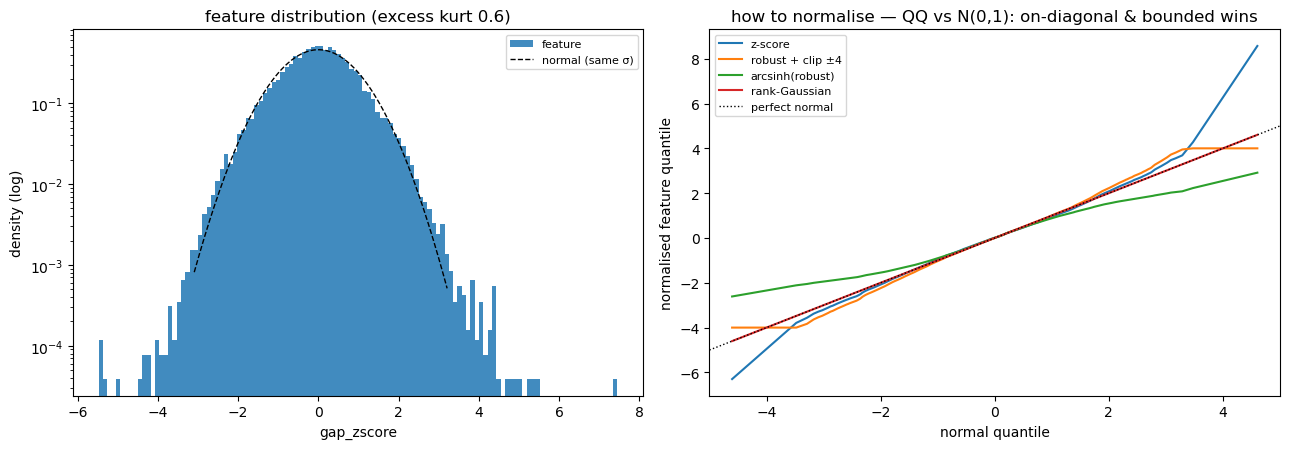

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = SRCS[0]; j = price_member[rep_ex]
f = feat_cache[(rep_ex, SPANS[j])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (byb<->{rep_ex}, span {SPANS[j]}): std={f.std():.2f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("gap_zscore"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it (shown for byb↔okx, span 1000). `gap_zscore` is already a z-score, so
its std is ≈**0.87** and it is essentially **symmetric** (skew **−0.00**) with only mild fat tails (excess
kurt **0.6**) — a plain rescale keeps the excess kurtosis low. But a thin-`σ_g` instant still leaves a large
`|z|` spike: a plain z-score peaks at **max|·| = 8.6**, violating the "no wild outliers" bar. The lightest
transform that *meets* it is a robust z-score followed by a clip (**robust + clip ±4 → max|·| = 4.0**) — clip
whenever you feed a network. The heavier transforms (arcsinh max|·| 2.9, rank-Gaussian 4.6) flatten the tails
further but throw away the meaningful gradations near the centre; the QQ-plot makes the call.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

`gap_dynamics` is a *gap between* exchanges (byb↔okx, byb↔bin), so it has to be per-exchange — there's no
single "pooled" version. But many features (trade-flow, order-flow imbalance, queue imbalance) *can* be
pooled into one number, and then you face a real choice: keep them **per-exchange**, collapse to **one
exchange**, or **pool** them all? The answer depends on the time-scale, so sweep it and compare the three.

> **The table below is an illustrative example for a poolable trade-flow feature — it is NOT computed for
> `gap_dynamics`** (whose real per-leg numbers are the heat-maps in §6, both legs kept). It just shows the
> typical pattern, predicting byb's next 100 ms. The time-scale column is labelled in ms / seconds only for
> readability — those wall-clock figures are just a translation of points on the trade-span N clock; the
> actual sweep is over trade-span N, as everywhere else.

| time-scale | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.22 | **0.23** | 0.22 | one exchange is enough — splitting just adds noise |
| ~500 ms | 0.11 | 0.12 | **0.16** | keep per-exchange — exchanges genuinely differ here |
| ≥ 2.5 s | 0.08 | 0.08 | 0.09 | exchanges agree — any one will do |

So: at the shortest scales the signal lives in one exchange; in a **middle band** the exchanges genuinely
differ (who's leading whom) and keeping them separate pays off; at long scales they all converge. In this
typical pattern pooling is rarely the best — it tends to blur the middle-band structure; that's why you
sweep and compare the three (per-exchange / single / pooled) rather than pool by default. (Longer prediction
horizons push the useful band wider, so in general sweep the horizon too.)

For `gap_dynamics` the analogous live question is whether keeping **both** cross-venue legs is worth it over
a single one across the span family — exactly what §6's per-leg heat-maps and the §6 gate table's per-leg
marginals answer. We keep **both** legs as the safe default (no fixed leader); the data says where each
earns its keep.

## 10. The verdict, and what it takes to ship

**Disposition: keep the PRICE head; the RATE head FAILS this block.** The two heads land in opposite places,
and the §6 gate tables say so:
- **Price head (direction) — clears every local gate, both legs.** The standardised z ships at span **1000**
  for both legs. A large `+z` precedes byb falling, so the feature's **standalone** rank-IC is **negative** —
  the reversion signature (okx −0.091, bin −0.153 at δ=0; echo-netted okx −0.125, bin −0.195). The Gate B
  *marginal* is a different, incremental quantity (added IC of the prediction vs target) and is **positive** by
  construction for a real signal: joint marginal **+0.126** (5/5 OOS folds, CI [0.108, 0.139]; bin +0.125,
  okx +0.069), companion **positive and rising** across all three regimes (+0.086 / +0.108 / +0.188). Gate A
  within bars per leg (scale 1.10 / 1.24, mean-track 0.004 / 0.008). It ships **RAW** — standardised by its own
  `σ_g`, the §6 scale gate confirms it (raw 1.10 vs /σ_ev 1.44, /λ_ev 2.05). **A single-block candidate** for
  the price head.
- **Rate head (intensity) — NOT shipped from this block.** The rate-span pick (N=10) posts a big *in-sample*
  `|z|→count` IC (+0.207), but it **does not clear its own gates**: Gate B marginal over the controls is
  **+0.000** (3/5 folds, CI [0.0, 0.0]) — the short-span signal *is* the volatility regime, gone once the
  momenta are controlled for — and Gate A **fails hard** (vol-bucket scale **77 / 39** ≫ 3, dispersion
  **0.88 / 1.33** ≫ 0.1). So there is **no standalone rate-head pass** to record. We still feed the
  **signed** z to the model (which can learn any residual magnitude itself), but we do **not** claim a
  rate-head edge for `gap_zscore` on this block.

Feed **both legs'** signed z in and let the model lean on whichever is dislocated; don't collapse to one
"leader." The feature needs **no** σ-division — it is standardised by its own `σ_g`. Never feed a
pre-computed `|z|` per leg — that destroys the sign and the cross-venue interaction.

**Cite the echo-netted IC, not the raw δ=0 IC.** The z's displacement leg contains byb's own contemporaneous
mid (§5), so the raw δ=0 IC mixes the cross-venue reversion with byb's own move. The honest headline is the
**echo-netted (partial) forward IC** (controlling for the trailing `[anchor−100 ms, anchor]` byb move): on
this block netting **strengthens** the edge — byb's own trailing move is a *continuation* (backward IC
+0.117 / +0.136) that *opposed* the reversion z, so removing it un-masks a larger cross-venue edge (**okx
−0.091 → −0.125, bin −0.153 → −0.195**). That netted value, not the raw δ=0 IC, is the price-head headline.
The **own reversion-speed read** (`gap_halflife`, the `ac1` reversion time) is a measured diagnostic only — it
reads **sub-tick** (≈0.3 ticks, the gap white at the tick clock), a degenerate gate, not a working one;
resolving a real reversion speed needs a slower (multi-tick / wall-time) increment, out of scope here.

**To ship (price head):**
- [✓] the streaming (constant-work-per-event) builder, matching this analysis version — §4 is **bit-exact on
      `ac1`** and **float32-grade on the well-conditioned z** over the full real block, both legs, both shipped spans
- [✓] the parity check (§4) passing (ac1 worst 1.2e-15; z worst 7.6e-7 well-conditioned)
- [✓] the gate results recorded — price head clears Gate A/B; **rate head fails Gate A/B (recorded, not shipped)**
- [✓] RAW-vs-normalise decision recorded with its measured scale (ships RAW, 1.10 < 3)
- [✓] echo-netted forward IC reported as the headline; backward IC disclosed
- [☐] multi-block OOS confirmation with the long embargo (this notebook is one block, one window)
- [☐] `gap_halflife` either dropped or recomputed on a slower (multi-tick) increment where reversion resolves
- [✓] the data quirks handled (bad zero-price prints filtered; byb/okx merged_levels, bin front_levels;
      same-`rx_time` bursts collapsed to one event; the shared trade clock ticks both gap EMAs once per timestamp)